In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import ols 
from scipy.stats import pearsonr

In [2]:
#Reading the data through pandas
data = pd.read_csv('../../Desktop/Data_Ances.csv')
data

,study_id,redcap_event_name,related_study_id,hiv_status,pid_scandate,Year,Age,Sex,Height,Weight,...,Impaired_Z,Unnamed: 50,Frontal_Thickness,Parietal_Thickness,Temporal_Thickness,Occipital_Thickness,Mean_Thickness,Unnamed: 56,Current_HIV_meds,Current_nonHIV_meds
0,500553A,CHAMPS,40001_MR1,1,500553A_032322,2022,32,0,68.0,207.0,...,0.0,NaN,2.380500,2.3003,2.864611,1.970625,2.404180,NaN,Odefsey,NaN
1,500557A,CHAMPS,40002_MR1,1,500557A_noscan,2022,43,1,70.0,351.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cabenuva,"amlodipine, bupropion, chlorthalidone, gabapen..."
2,214653D,CHAMPS,40003_MR1,1,214653D_041322,2022,61,1,59.0,170.0,...,0.0,NaN,2.474227,2.2692,2.787444,1.853750,2.430590,NaN,Biktarvy,"Albuterol, amlodipine, ammonium lactate, cetir..."
3,212176H,CHAMPS,40004_MR1,1,212176H_noscan,2022,79,0,69.0,240.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Biktarvy,"albuterol, 90mcg/actuation aspirin, 81mg at..."
4,214297L,CHAMPS,40005_MR1,1,214297L_050622,2022,68,0,73.0,174.0,...,0.0,NaN,2.371182,2.1918,2.573944,1.840750,2.320585,NaN,"Reyataz, Descovy, Norvir","Cleocint, Marinol, Revatio, Vit D3"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
500,500733A,baseline_arm_16,50280_MR1,1,500733A_110424,2024,32,0,65.0,150.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Biktarvy,NaN
501,500614A,baseline_arm_16,50281_MR1,0,500614A_110624,2024,33,1,67.0,138.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DepoProvera
502,500736A,baseline_arm_16,50282_MR1,0,500736A_111124,2024,80,0,67.0,202.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"lisinopril, hydralazine, amlodipine, timolol, ..."
503,500737A,baseline_arm_16,50283_MR1,0,500737A_111324,2024,44,0,69.0,190.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"metformin, jardiance, losartan, insulin"


In [3]:
#There are duplicates of the same individuals participating
#from different studies, however, we want to only drop the duplicate that has data we need
#But we also need to only pick the ones that have entries for our SII calculations

#The easiest way to do this would be to drop the value of NaN's for missing values of our main and most important calculation

missing = data.dropna(subset=['Abs_Neutrophil','Abs_Platelets','Abs_Lymphocytes'], how='any').copy()

#Then drop the duplicates afterward
data_clean = missing.drop_duplicates(subset=['study_id']).copy()
data_clean

#Hippa-proofing it for git
data_clean = data_clean.drop(['study_id','redcap_event_name','related_study_id'], axis=1)
data_clean.to_csv('../output/data_clean.csv', index=False)

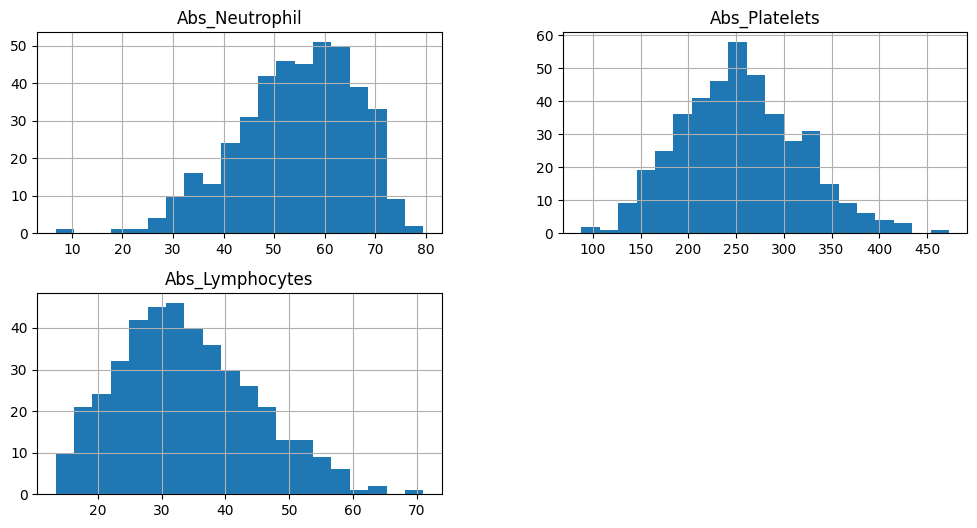

In [4]:
#Check for any errors in blood work data entry  
clean = data_clean[['Abs_Neutrophil','Abs_Platelets','Abs_Lymphocytes']].hist(bins=20, figsize=(12,6))
plt.savefig("Blood_work_error_check.png")

In [5]:
data_clean[['Abs_Neutrophil','Abs_Platelets','Abs_Lymphocytes']].describe()

,Abs_Neutrophil,Abs_Platelets,Abs_Lymphocytes
count,418.000000,418.000000,418.000000
mean,54.455502,254.167464,33.802392
std,11.588884,62.502418,10.588349
min,6.800000,88.000000,13.400000
25%,47.025000,208.250000,25.900000
50%,55.550000,252.500000,32.700000
75%,62.900000,295.750000,40.675000
max,79.500000,473.000000,71.000000


In [6]:
entry_testing = data_clean.copy()
entry_testing.loc[(entry_testing['Abs_Neutrophil'] < 10) |
               (entry_testing['Abs_Platelets'] < 100) |
               (entry_testing['Abs_Lymphocytes'] < 15),['Abs_Neutrophil','Abs_Platelets','Abs_Lymphocytes']]

,Abs_Neutrophil,Abs_Platelets,Abs_Lymphocytes
47,79.5,384.0,13.4
231,78.5,88.0,16.7
274,6.8,132.0,71.0
402,74.6,180.0,13.5
476,70.8,107.0,13.6


In [7]:
#Dropping weird Neutrophile value
finalData = data_clean.drop(index=274)
finalData[['Abs_Neutrophil','Abs_Platelets','Abs_Lymphocytes']].describe()

,Abs_Neutrophil,Abs_Platelets,Abs_Lymphocytes
count,417.000000,417.000000,417.000000
mean,54.569784,254.460432,33.713189
std,11.364539,62.289484,10.442631
min,20.600000,88.000000,13.400000
25%,47.100000,209.000000,25.900000
50%,55.700000,253.000000,32.700000
75%,62.900000,296.000000,40.600000
max,79.500000,473.000000,63.300000


In [8]:
#The new calculation, SII = neutrophil*platelet/lymphocytes, will be added as a new column
finalData["SII"] = ((finalData["Abs_Neutrophil"])*(finalData["Abs_Platelets"]))/(finalData["Abs_Lymphocytes"])

In [9]:
#Age demographics in HIV+ cohort vs HIV- cohort using independent variable t-test

#Splitting data via HIV status 
hiv_positive = finalData[finalData['hiv_status'] == 1]['Age']
hiv_negative = finalData[finalData['hiv_status'] == 0]['Age']

#Perform T-test
t_statistic, p_value = stats.ttest_ind(hiv_positive, hiv_negative)
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

T-statistic: 2.3041869453344663
P-value: 0.021705276967718037


In [10]:
#Gender demographics in HIV+ cohort vs HIV- cohort using a Chi-square test
contingency_table = pd.crosstab(finalData['Sex'], finalData['hiv_status']) 

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square statistic: 12.8318
P-value: 0.0003
Degrees of freedom: 1


In [11]:
# ANCOVA: Compare SII between HIV groups, controlling for sex and age
model = ols('SII ~ C(hiv_status) + C(Sex) + Age', data=finalData).fit() #Hiv_status and Sex are defined as catagorical
ancova_table = sm.stats.anova_lm(model, typ=2) 
print(ancova_table)

print(finalData.groupby('hiv_status')['SII'].agg(['mean', 'std', 'count']))

                     sum_sq     df          F    PR(>F)
C(hiv_status)  1.189457e+06    1.0  13.932391  0.000216
C(Sex)         3.983552e+04    1.0   0.466603  0.494937
Age            6.196772e+05    1.0   7.258428  0.007345
Residual       3.525925e+07  413.0        NaN       NaN
                  mean         std  count
hiv_status                               
0           537.292624  300.840982    218
1           433.332853  286.474709    199


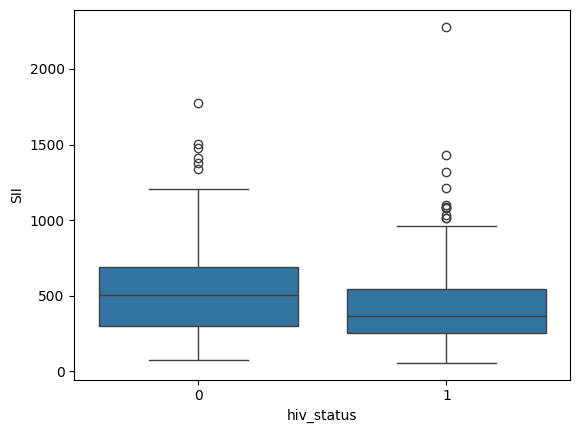

In [12]:
#Now I will create a boxplot for SII values of those who are HIV + and those that are HIV-
sii = sns.boxplot(x="hiv_status", y="SII", data=finalData, showcaps=True)
plt.savefig("../output/boxplot_SII_by_HIV_Status.png")

In [13]:
#Now we will use a pearson correlation in order to analyze corticol thickness in individuals w/&o HIV

#Once again, we will split the two groups
hiv_positive = finalData[finalData['hiv_status'] == 1]
hiv_negative = finalData[finalData['hiv_status'] == 0]

#Z-Test scores were calculated from a neuropsych eval, we have catagories that include Delayed Recall, Executive Function,ect.
#We will make an array for every column for our domain Z-score in order to compare how SII may impact cognition

z_columns = ['Learn_Z', 'Delay_Z', 'EF_Z', 'PM_Z', 'Lang_Z', 'Total_Z']

for z in z_columns:
    clean_pos = hiv_positive[['SII', z]].dropna() #dropping all missing values 
    clean_neg = hiv_negative[['SII', z]].dropna()
    
    r_pos, p_pos = pearsonr(clean_pos['SII'], clean_pos[z]) #Pearson correlation 
    sigPos = "**" if p_pos < 0.05 else "  " #This is to show significent p values 
    
    r_neg, p_neg = pearsonr(clean_neg['SII'], clean_neg[z])
    sigNeg = "**" if p_neg < 0.05 else "  " #This is to show significent p values 
    
    print(f"{z}:")
    print(f" HIV+: r = {r_pos:.4f}, p = {p_pos:.4f}{sigPos}")
    print(f" HIV-: r = {r_neg:.4f}, p = {p_neg:.4f}{sigNeg}")

Learn_Z:
 HIV+: r = -0.1598, p = 0.0256**
 HIV-: r = -0.1315, p = 0.0548  
Delay_Z:
 HIV+: r = -0.0695, p = 0.3340  
 HIV-: r = -0.1237, p = 0.0710  
EF_Z:
 HIV+: r = -0.0062, p = 0.9315  
 HIV-: r = 0.0617, p = 0.3690  
PM_Z:
 HIV+: r = -0.0909, p = 0.2063  
 HIV-: r = -0.0553, p = 0.4209  
Lang_Z:
 HIV+: r = 0.0312, p = 0.6663  
 HIV-: r = -0.0344, p = 0.6164  
Total_Z:
 HIV+: r = -0.0809, p = 0.2609  
 HIV-: r = -0.0648, p = 0.3452  


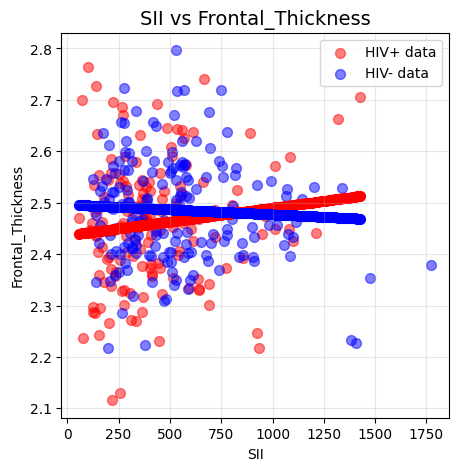

Frontal_Thickness p = 0.1116  
Frontal_Thickness p = 0.4054  


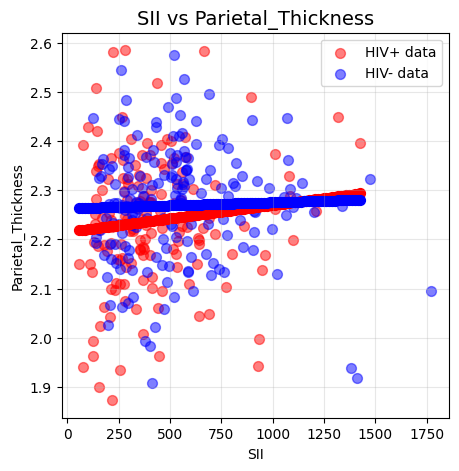

Parietal_Thickness p = 0.1477  
Parietal_Thickness p = 0.6383  


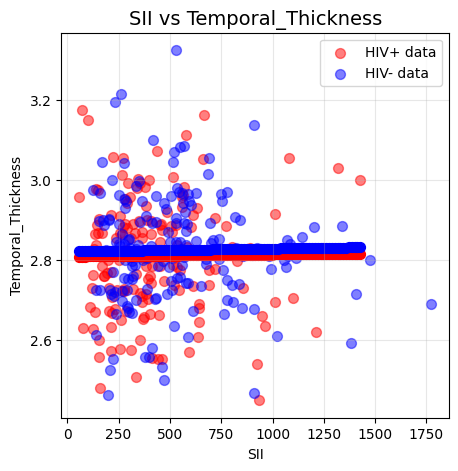

Temporal_Thickness p = 0.8878  
Temporal_Thickness p = 0.8056  


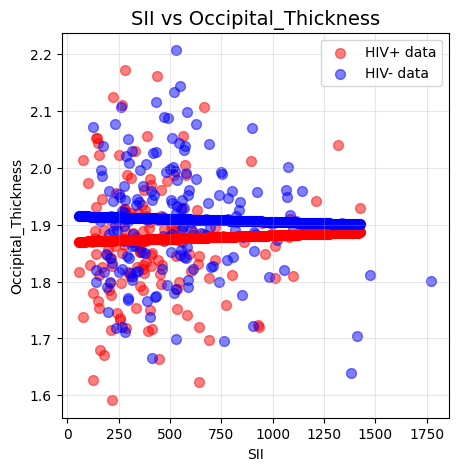

Occipital_Thickness p = 0.6992  
Occipital_Thickness p = 0.6656  


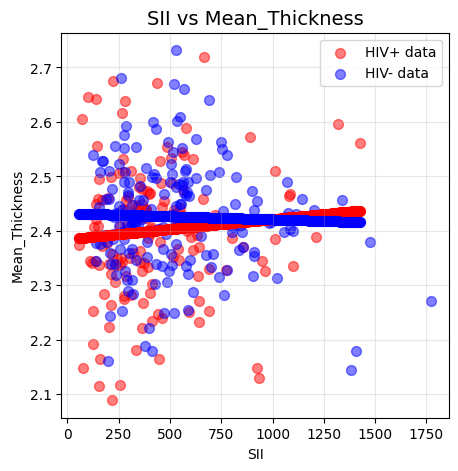

Mean_Thickness p = 0.2459  
Mean_Thickness p = 0.5950  


In [19]:
#Now it is time to identify an association between brain cortical thickness and SII in individuals with and without HIV
#Similarly, we will have to create an array of all of the recorded cortical thickness
thickness_columns = ['Frontal_Thickness', 'Parietal_Thickness','Temporal_Thickness', 'Occipital_Thickness', 'Mean_Thickness']

for thick in thickness_columns:
    clean_pos = hiv_positive[['SII', thick, 'Sex','Age']].dropna() #dropping all missing values 
    clean_neg = hiv_negative[['SII', thick, 'Sex','Age']].dropna()
    
    #Fit regression modeles accounting for both age and sex
    model_pos = ols(f"{thick} ~ SII + Age + C(Sex)", data=clean_pos).fit()
    model_neg = ols(f"{thick} ~ SII + Age + C(Sex)", data=clean_neg).fit()
    
    
    #Adding the predicted values based on the prior model
    #What thickness does the regression model predict for each person
    clean_pos['predicted'] = model_pos.predict(clean_pos)
    clean_neg['predicted'] = model_neg.predict(clean_neg)
    
    #Plotting predicted thickness as a function of SII
    x = np.linspace(clean_pos['SII'].min(), clean_pos['SII'].max(), 100) #Producing 100 points evenly across SII
    y_pos = model_pos.predict(pd.DataFrame({'SII':x,'Age':clean_pos['Age'].mean(),'Sex': clean_pos['Sex'].mode()[0]}))
    y_neg = model_neg.predict(pd.DataFrame({'SII':x,'Age':clean_neg['Age'].mean(),'Sex': clean_neg['Sex'].mode()[0]}))
    
    #Plot
    plt.figure(figsize=(5, 5))
    
    #Scatter plot of the thickness and SII of actual data points
    plt.scatter(clean_pos['SII'], clean_pos[thick], color='red', s=50, alpha=0.5, label='HIV+ data')
    plt.scatter(clean_neg['SII'], clean_neg[thick], color='blue', s=50, alpha=0.5, label='HIV- data')

    #Scatter plot of the thickness and SII of linear regression
    plt.scatter(x,y_pos, color='red', s=50) 
    plt.scatter(x,y_neg, color='blue', s=50)
    
    plt.xlabel('SII')
    plt.ylabel(thick)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.title(f'SII vs {thick}', fontsize=14)
    
    #Saving the graphs for git + presentation
    plt.savefig(f'../output/SII_Cortical_{thick}_HIV.png', dpi=300, bbox_inches='tight') 
    plt.show()
    
    #Printing out and formating the p values 
    p_pos = model_pos.pvalues['SII']
    p_neg = model_neg.pvalues['SII']
    
    sig_pos = "**" if p_pos < 0.05 else "  "
    sig_neg = "**" if p_neg < 0.05 else "  "
    
    print(f"{thick} p = {p_pos:.4f}{sig_pos}")
    print(f"{thick} p = {p_neg:.4f}{sig_neg}")
    